## Import Libraries

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score   
from sklearn.pipeline import Pipeline        

import warnings
warnings.filterwarnings("ignore")        # Ignore all warnings - to keeep output clean

## Load Data & Data Understanding

In [76]:
df = pd.read_csv("new.csv")
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100818,2228.0,7.0,5.0,6.3,42.0,8.1,5271.0,1.0,0.0,1.0,34740679.0
1,104126,938.0,3.0,NaN,NaN,15.0,22.7,1894.0,NaN,0.0,10.0,10994288.0
2,102410,904.0,2.0,2.0,8.1,28.0,NaN,2448.0,NaN,0.0,1.0,16285478.0
3,103510,1303.0,2.0,2.0,7.9,8.0,20.2,3174.0,0.0,NaN,4.0,24681961.0
4,103672,2217.0,6.0,5.0,8.5,NaN,27.5,NaN,1.0,1.0,18.0,46450777.0


In [77]:
df.shape

(4350, 12)

In [78]:
df.columns

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='object')

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4350 entries, 0 to 4349
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4350 non-null   int64  
 1   area_sqft             4133 non-null   float64
 2   bedrooms              4133 non-null   float64
 3   bathrooms             4133 non-null   float64
 4   location_score        4133 non-null   float64
 5   age_years             4133 non-null   float64
 6   distance_city_km      4133 non-null   float64
 7   lot_size_sqft         4133 non-null   float64
 8   has_garage            4133 non-null   float64
 9   has_pool              4133 non-null   float64
 10  renovation_years_ago  4133 non-null   float64
 11  house_price_inr       4133 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 407.9 KB


In [80]:
df.isnull().sum()

house_id                  0
area_sqft               217
bedrooms                217
bathrooms               217
location_score          217
age_years               217
distance_city_km        217
lot_size_sqft           217
has_garage              217
has_pool                217
renovation_years_ago    217
house_price_inr         217
dtype: int64

In [81]:
df.duplicated().sum()

43

## Basic Cleaning

In [83]:
df_clean = df.copy()
df_clean = df_clean.drop(columns='house_id')

print("Before removing duplicates:", df_clean.shape)
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", df_clean.shape)

df_clean = df_clean.dropna(subset=["house_price_inr"])
df_clean = df_clean.reset_index(drop=True)
df_clean.head(1)

Before removing duplicates: (4350, 11)
After removing duplicates: (4307, 11)


,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,2228.0,7.0,5.0,6.3,42.0,8.1,5271.0,1.0,0.0,1.0,34740679.0


## Exploratory Data Analysis

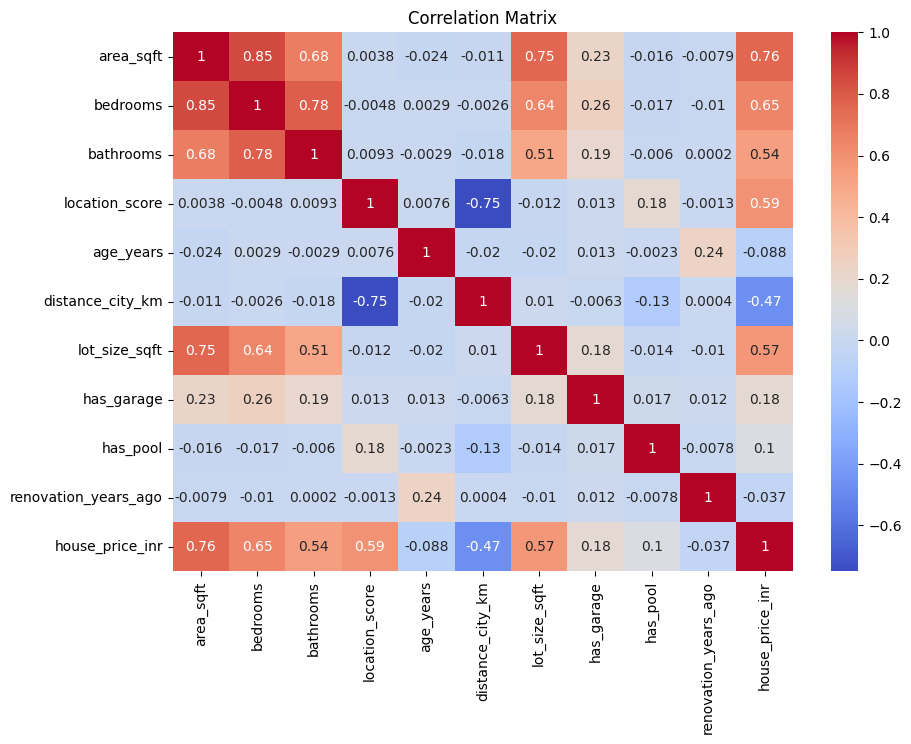

In [85]:
plt.figure(figsize=(10,7))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")         # annot = show value , cmap = color 
plt.title("Correlation Matrix")
plt.show()

**Correlation Matrix Insights**

- The correlation matrix shows that area_sqft (0.76) has the strongest positive impact on house price.
- Bedrooms (0.65), bathrooms (0.54), location_score (0.59), and lot_size_sqft (0.57) also positively influence price.
- Distance_city_km (-0.47) has a negative correlation, meaning houses farther from the city are cheaper.
- Features like age_years and renovation_years_ago have very weak impact on price.
- Some features like area_sqft and bedrooms are highly correlated, indicating multicollinearity.
- Overall, area, location, and distance are the most important factors affecting house prices.

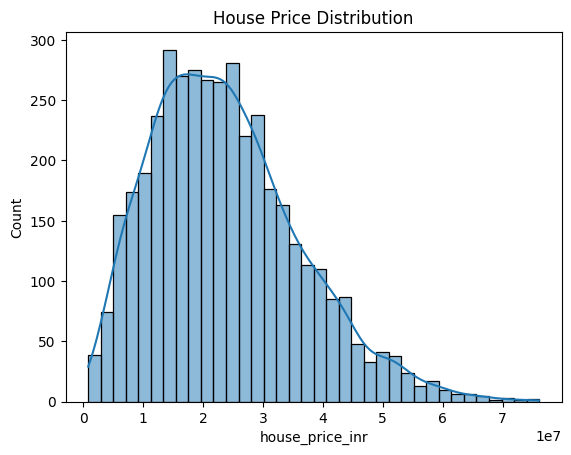

In [86]:
sns.histplot(df_clean["house_price_inr"], kde=True)
plt.title("House Price Distribution")
plt.show()

 **House Price Distribution Insights**

- The distribution of house_price_inr is right-skewed, meaning most houses are in the lower to mid price range.
- A few houses have very high prices, creating a long tail on the right side.
- This indicates the presence of high-value outliers in the dataset.
- The data is not perfectly normally distributed.

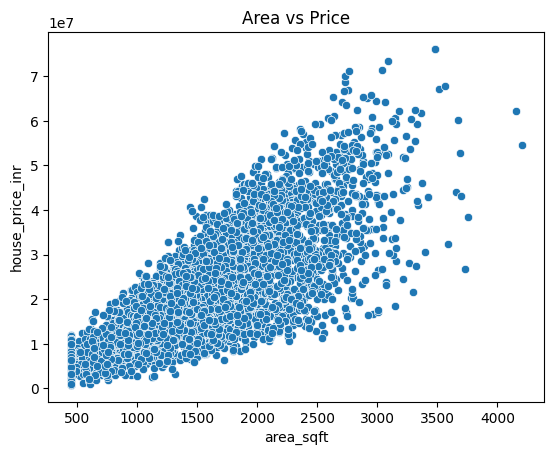

In [87]:
sns.scatterplot(x=df_clean["area_sqft"], y=df_clean["house_price_inr"])
plt.title("Area vs Price")
plt.show()

**Area vs Price Insights**

- There is a strong positive relationship between area_sqft and house_price_inr.
- As the area increases, the house price also increases.
- The data points show an upward trend, indicating a linear relationship.
- Some spread is visible at higher area values, suggesting variability in pricing.
- A few outliers can also be observed.
- Overall, area_sqft is a very important feature for predicting house price.

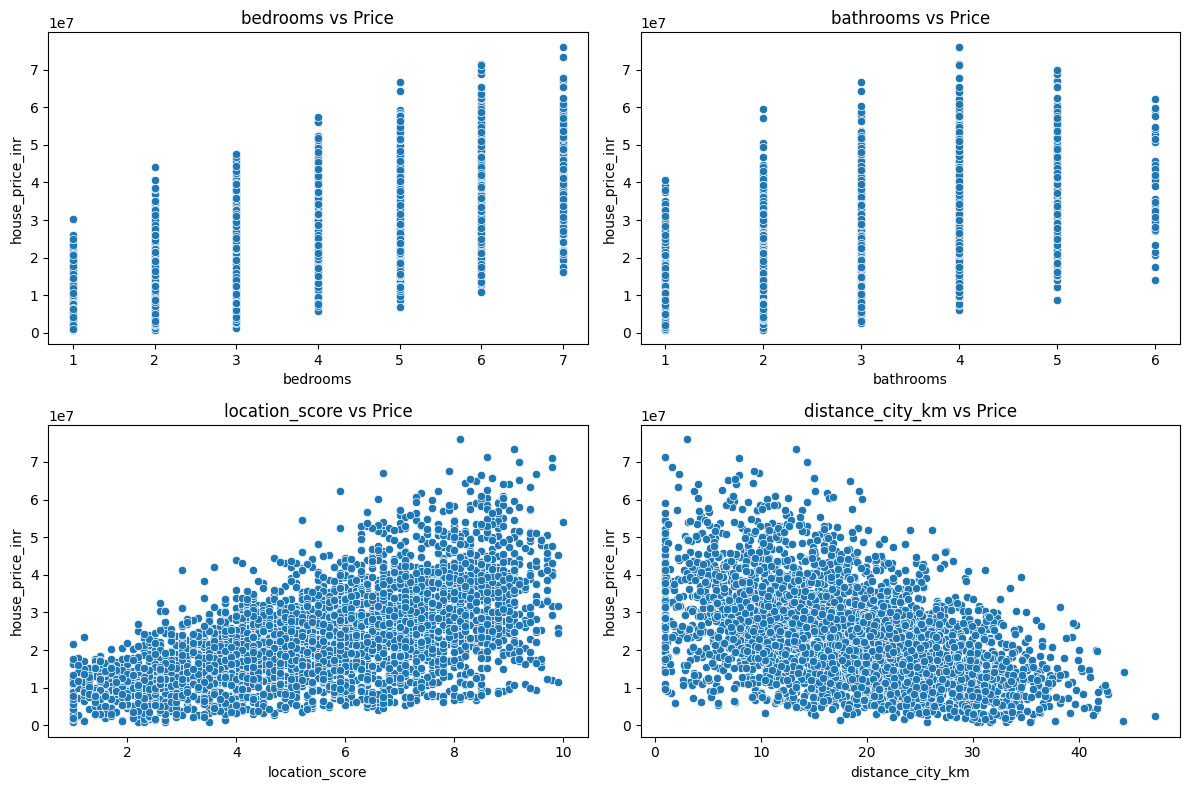

In [88]:
features = ["bedrooms", "bathrooms", "location_score", "distance_city_km"]
plt.figure(figsize=(12,8))
for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)   
    sns.scatterplot(x=df_clean[col], y=df_clean["house_price_inr"])
    plt.title(f"{col} vs Price")
plt.tight_layout()
plt.show()

**Feature vs Price Insights**

- Bedrooms and bathrooms show a positive relationship with house price, as price increases with more rooms.
- Location_score also has a strong positive trend, indicating better locations have higher prices.
- Distance_city_km shows a negative relationship, meaning houses farther from the city are cheaper.
- Bedrooms and bathrooms appear as discrete steps, creating vertical patterns in the plot.
- There is some spread in data, indicating other factors also influence price.
- Overall, location and distance are strong predictors along with size-related features.

## Evaluate Model Function

In [90]:
def evaluate_model(y_true, y_pred, p):
    n = len(y_true)
    r2     = r2_score(y_true, y_pred)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    mae    = mean_absolute_error(y_true, y_pred)
    mse    = mean_squared_error(y_true, y_pred)
    rmse   = np.sqrt(mse)
    return {"R2": r2, "Adj_R2": adj_r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

## Train-Test Split

In [92]:
X = df_clean.drop(columns=["house_price_inr"])
y = df_clean["house_price_inr"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (3272, 10), Test: (818, 10)


### 1. Simple Linear Regression (SLR) Pipeline — only `area_sqft`

In [95]:
slr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('model',   LinearRegression())
])

X_slr_train = X_train[["area_sqft"]]
X_slr_test  = X_test[["area_sqft"]]

slr_pipeline.fit(X_slr_train, y_train)
y_pred_slr = slr_pipeline.predict(X_slr_test)

print("Intercept:", slr_pipeline.named_steps['model'].intercept_)
print("Slope    :", slr_pipeline.named_steps['model'].coef_)

Intercept: 23724259.28300734
Slope    : [9234635.00761061]


In [96]:
slr_metrics = evaluate_model(y_test, y_pred_slr, p=1)
slr_metrics

{'R2': 0.5411749951811945,
 'Adj_R2': 0.5406127096360733,
 'MAE': 6426947.688326521,
 'MSE': 69546866559753.05,
 'RMSE': 8339476.3960187}

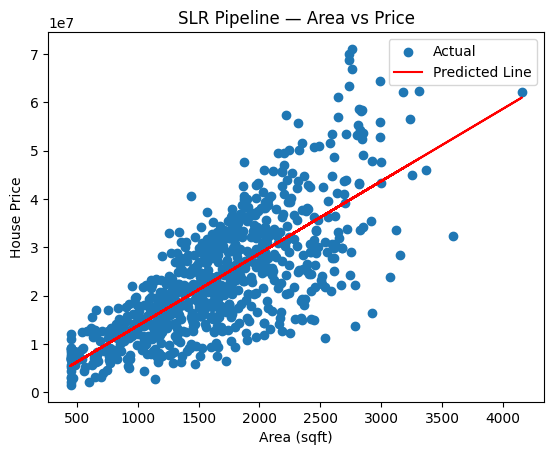

In [97]:
plt.scatter(X_slr_test, y_test, label='Actual')
plt.plot(X_slr_test, y_pred_slr, color='red', label='Predicted Line')
plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("SLR Pipeline — Area vs Price")
plt.legend()
plt.show()

**Regression Line Plot:**

- The scatter plot shows the relationship between area and house price.
- The red line represents the regression line predicted by the model.
- As area increases, house price also increases, showing a positive relationship.
- The line fits the data reasonably well, indicating a good linear trend.

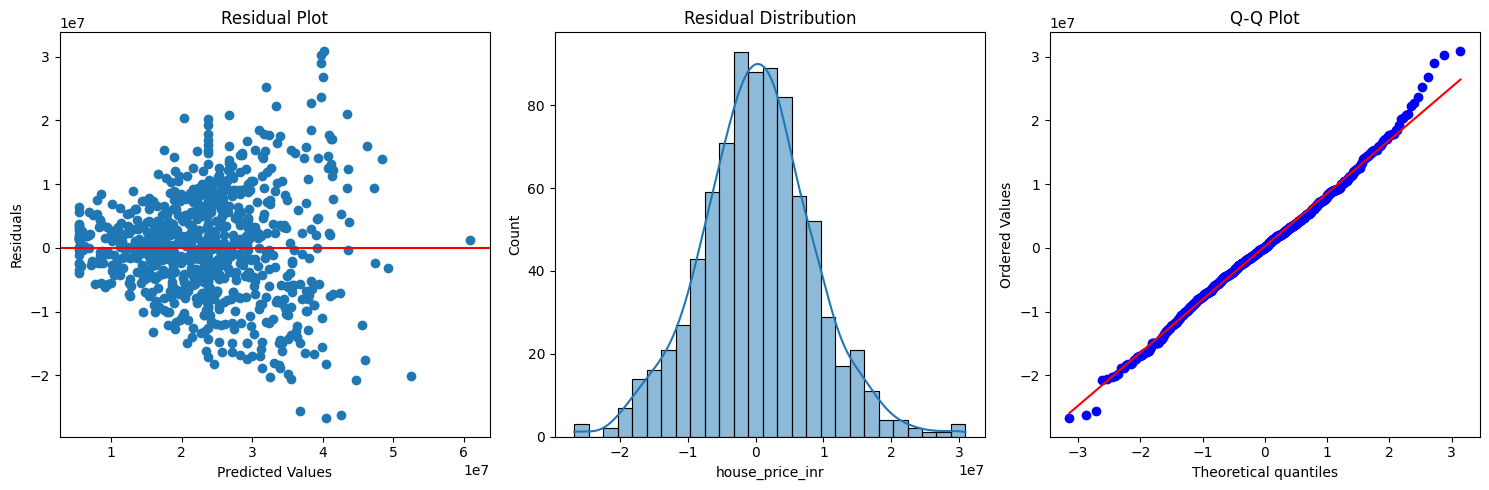

In [98]:
residuals = y_test - y_pred_slr

plt.figure(figsize=(15,5))

#  1. Residual Plot
plt.subplot(1, 3, 1)
plt.scatter(y_pred_slr, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

#  2. Residual Distribution
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

#  3. Q-Q Plot
plt.subplot(1, 3, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")

plt.tight_layout()
plt.show()

**Linear Regression Assumptions Validation:**

- Residual plot shows that most points are randomly scattered around zero, indicating that the linearity assumption is mostly satisfied.
- However, slight spread increase at higher predicted values suggests mild heteroscedasticity (variance is not perfectly constant).
- The residual distribution appears approximately normal, though slightly skewed at the tails.
- The Q-Q plot shows most points lying close to the straight line, confirming that residuals are nearly normally distributed.
- Overall, the linear regression assumptions are reasonably satisfied, with minor deviations that do not severely impact the model.
- Intercept of SLR and MLR are almost same because data is scaled.
- After scaling, all features have mean ≈ 0.
- Intercept represents the predicted value when all features are zero (i.e., average case).
- Therefore, intercept becomes approximately equal to the mean of the target variable.
- This is why both models show similar intercept values.

### 2. Multiple Linear Regression (MLR) Pipeline — all features

In [100]:
mlr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('model',   LinearRegression())
])

mlr_pipeline.fit(X_train, y_train)
y_pred_mlr = mlr_pipeline.predict(X_test)

print("Intercept:", mlr_pipeline.named_steps['model'].intercept_)
print("Slopes   :", mlr_pipeline.named_steps['model'].coef_)

Intercept: 23724259.283007335
Slopes   : [ 7331885.87996088  1051319.06021213   450556.44668594  6337695.5506571
  -903739.95773704 -1102741.40576851   922489.08018711     9910.64429794
   178869.64859092  -150471.47813278]


In [101]:
mlr_metrics = evaluate_model(y_test, y_pred_mlr, p=X_train.shape[1])
mlr_metrics

{'R2': 0.883724870345368,
 'Adj_R2': 0.8822840385033032,
 'MAE': 3083889.2321387636,
 'MSE': 17624520985952.258,
 'RMSE': 4198156.85580616}

### 3. Polynomial Regression Pipeline (degree=2)

In [103]:
poly_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('poly',    PolynomialFeatures(degree=2)),
    ('model',   LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

n_poly_features = poly_pipeline.named_steps['poly'].n_output_features_
print(f"Polynomial features count: {n_poly_features}")

Polynomial features count: 66


In [104]:
poly_metrics = evaluate_model(y_test, y_pred_poly, p=n_poly_features)
poly_metrics

{'R2': 0.9291136967970383,
 'Adj_R2': 0.9228840083664185,
 'MAE': 2275007.846186487,
 'MSE': 10744663472988.902,
 'RMSE': 3277905.3483877326}

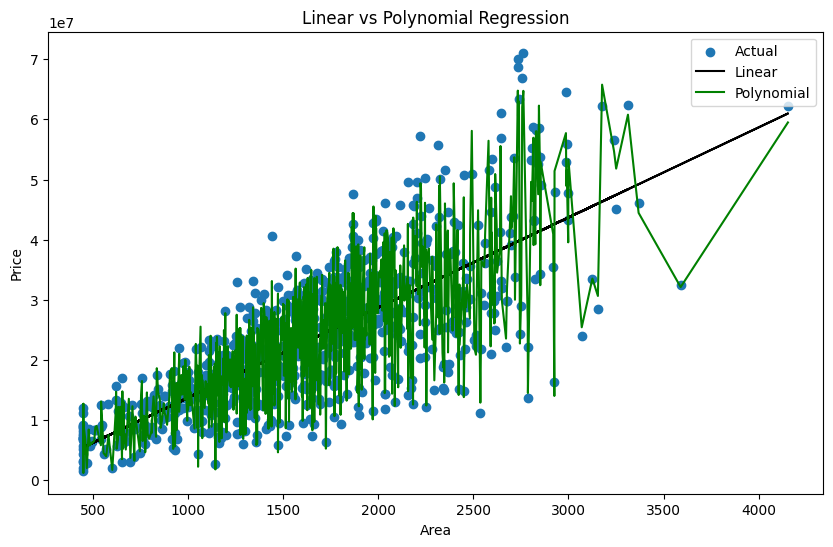

In [105]:
plt.figure(figsize=(10,6))

# Actual
plt.scatter(X_slr_test, y_test, label='Actual')

# Linear
plt.plot(X_slr_test, y_pred_slr, color='black', label='Linear')

# Polynomial (sorted for smooth curve)
sorted_idx = X_slr_test.values.flatten().argsort()
plt.plot(X_slr_test.values.flatten()[sorted_idx], 
         y_pred_poly[sorted_idx], 
         color='green', label='Polynomial')

plt.legend()
plt.title("Linear vs Polynomial Regression")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

**Linear vs Polynomial Regression Comparison:**
- The linear regression line shows a simple straight-line relationship between area and price.
- Polynomial regression captures more complex patterns but appears highly irregular and noisy.
- The polynomial curve fluctuates significantly, indicating overfitting to the data.
- While polynomial may achieve higher accuracy, it does not generalize well due to high variance.
- Linear regression underfits slightly, whereas polynomial regression overfits the dataset.

In [106]:
print("SLR R2:", slr_metrics["R2"])
print("Polynomial R2:", poly_metrics["R2"])

SLR R2: 0.5411749951811945
Polynomial R2: 0.9291136967970383


**Overfitting and Underfitting Analysis:**
- Underfitting occurs when the model is too simple and fails to capture patterns (e.g., SLR).
- Overfitting occurs when the model is too complex and captures noise along with patterns (e.g., Polynomial).
- SLR shows underfitting as it has lower R² and higher errors.
- Polynomial Regression may show overfitting due to very high R² and complexity.
- A good model (like MLR) balances both bias and variance.

### 4. Gradient Descent Pipelines (Batch / SGD)

In [108]:
# Batch GD (SGDRegressor full data)
bgd_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('model',   SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01))
])
bgd_pipeline.fit(X_train, y_train)
y_pred_batch = bgd_pipeline.predict(X_test)
bgd_metrics = evaluate_model(y_test, y_pred_batch, p=X_train.shape[1])
bgd_metrics
print("Batch GD done ")


Batch GD done 


In [109]:
# Stochastic GD
sgd_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('model',   SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01))
])
sgd_pipeline.fit(X_train, y_train)
y_pred_sgd = sgd_pipeline.predict(X_test)
sgd_metrics = evaluate_model(y_test, y_pred_sgd, p=X_train.shape[1])
sgd_metrics
print("SGD done ")

SGD done 


### 5. Mini-Batch GD Pipeline

In [111]:
imputer_mb = SimpleImputer(strategy='mean')
scaler_mb  = StandardScaler()

X_train_mb = scaler_mb.fit_transform(imputer_mb.fit_transform(X_train))
X_test_mb  = scaler_mb.transform(imputer_mb.transform(X_test))

mini_batch = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.01, warm_start=True)

batch_size = 32
for epoch in range(50):
    indices   = np.random.permutation(len(X_train_mb))
    X_shuffled = X_train_mb[indices]
    y_shuffled = y_train.iloc[indices].values
    for i in range(0, len(X_train_mb), batch_size):
        mini_batch.fit(X_shuffled[i:i+batch_size], y_shuffled[i:i+batch_size])

y_pred_mini = mini_batch.predict(X_test_mb)
mgd_metrics = evaluate_model(y_test, y_pred_mini, p=X_train.shape[1])
mgd_metrics
print("Mini-Batch GD done ")

Mini-Batch GD done 


## Model Comparison

In [113]:
all_models = {
    "SLR":        slr_metrics,
    "MLR":        mlr_metrics,
    "Polynomial": poly_metrics,
    "Batch GD":   bgd_metrics,
    "SGD":        sgd_metrics,
    "Mini-Batch": mgd_metrics,
}

print(f"{'Model':<12} {'R2':>8} {'Adj_R2':>10} {'MAE':>14} {'RMSE':>16}")
print("-"*62)
for name, m in all_models.items():
    print(f"{name:<12} {m['R2']:>8.4f} {m['Adj_R2']:>10.4f} {m['MAE']:>14.2f} {m['RMSE']:>16.2f}")

Model              R2     Adj_R2            MAE             RMSE
--------------------------------------------------------------
SLR            0.5412     0.5406     6426947.69       8339476.40
MLR            0.8837     0.8823     3083889.23       4198156.86
Polynomial     0.9291     0.9229     2275007.85       3277905.35
Batch GD       0.8768     0.8753     3078236.66       4320729.21
SGD            0.8787     0.8772     3249311.76       4287798.28
Mini-Batch     0.8811     0.8797     3143847.53       4244823.78


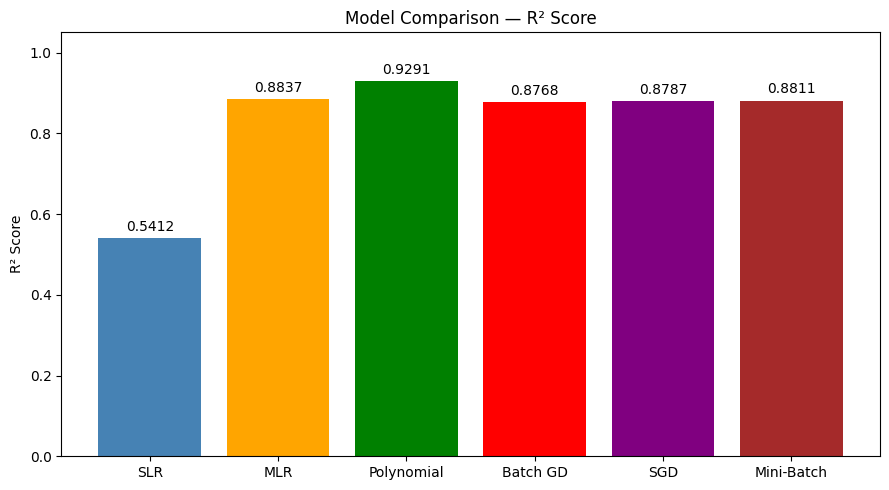

In [114]:
names     = list(all_models.keys())
r2_scores = [all_models[m]['R2'] for m in names]

plt.figure(figsize=(9,5))
bars = plt.bar(names, r2_scores, color=['steelblue','orange','green','red','purple','brown'])
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.title("Model Comparison — R² Score")
plt.ylabel("R² Score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Bias-Variance Analysis

In [116]:
def bias_variance_analysis(pipeline, X_train_, X_test_, y_train, y_test):
    train_r2 = r2_score(y_train, pipeline.predict(X_train_))
    test_r2  = r2_score(y_test,  pipeline.predict(X_test_))
    bias     = 1 - train_r2
    variance = train_r2 - test_r2
    return train_r2, test_r2, bias, variance

slr_tr, slr_te, slr_b, slr_v   = bias_variance_analysis(slr_pipeline, X_slr_train, X_slr_test, y_train, y_test)
mlr_tr, mlr_te, mlr_b, mlr_v   = bias_variance_analysis(mlr_pipeline, X_train, X_test, y_train, y_test)
poly_tr, poly_te, poly_b, poly_v = bias_variance_analysis(poly_pipeline, X_train, X_test, y_train, y_test)

print(f"SLR  — Bias: {slr_b:.4f}  Variance: {slr_v:.4f}")
print(f"MLR  — Bias: {mlr_b:.4f}  Variance: {mlr_v:.4f}")
print(f"Poly — Bias: {poly_b:.4f}  Variance: {poly_v:.4f}")

SLR  — Bias: 0.4500  Variance: 0.0089
MLR  — Bias: 0.1057  Variance: 0.0106
Poly — Bias: 0.0638  Variance: 0.0071


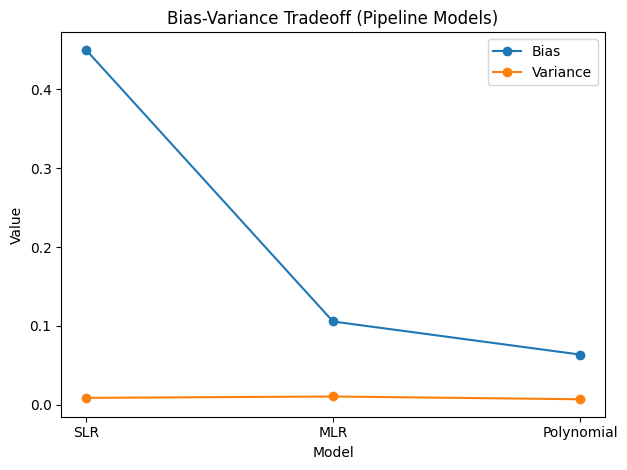

In [117]:
model_names = ["SLR", "MLR", "Polynomial"]
bias_vals   = [slr_b, mlr_b, poly_b]
var_vals    = [slr_v, mlr_v, poly_v]

plt.plot(model_names, bias_vals, marker='o', label="Bias")
plt.plot(model_names, var_vals,  marker='o', label="Variance")
plt.title("Bias-Variance Tradeoff (Pipeline Models)")
plt.xlabel("Model")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

**Model Comparison Insights**

- Polynomial Regression shows the highest R2 score, indicating best performance.
- MLR and Gradient Descent variants (Batch, Mini-Batch, SGD) also perform well.
- SLR has the lowest R2 score, showing it is too simple for this dataset.
- Gradient Descent models give results close to MLR, confirming proper convergence.
- Overall, Polynomial gives best accuracy but may risk overfitting.

## **Final Conclusion – House Price Prediction Project:**
- In this project, multiple regression models were applied to predict house prices.
- Simple Linear Regression (SLR) performed poorly due to limited feature usage.
- Multiple Linear Regression (MLR) showed significant improvement by using all features.
- Polynomial Regression achieved the highest R2 score, indicating best fit to the data.
- Gradient Descent models (Batch, Mini-Batch, Stochastic) performed similarly to MLR, showing proper convergence.
- However, Polynomial Regression may lead to overfitting due to high complexity.
- Adjusted R2 helped in evaluating model performance more accurately by penalizing extra features.
- MLR provides a good balance between bias and variance, making it a reliable choice.

## **Final Model Selection:**
 - MLR is selected as the best model due to its stability, interpretability, and balanced performance.

## **Key Learnings:**
 - Data preprocessing (handling missing values, scaling) is critical.
 - Model performance depends on feature selection and data quality.
 - Bias-variance tradeoff is important for selecting the right model.
 - Evaluation metrics like R2 and Adjusted R2 are essential for comparison.